In [3]:
from data import build_all
from distances import compute_euclidean_distances, compute_mahalanobis_distances
from arsenal import compare_all_arsenals, arsenal_internal_distances, real_arsenal_silhouette_scores, PITCH_CHAR_FEATURES
from biomech import evaluate_biomech_features, biomech_threshold_coverage, biomech_threshold_calibration, plot_threshold_calibration
from stability import stability_analysis, plot_stability


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

In [4]:
import importlib
import arsenal

importlib.reload(arsenal)

<module 'arsenal' from '/Users/kids/Pitcher Similarity/arsenal.py'>

In [5]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

In [6]:
pitch_type_summ.head()

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,425794,"Wainwright, Adam",R,2021,82.729744,-1.333487,6.222359,-1.152821,0.643179,1714.097938,6.495897,54.000974,222.546392,43.993229,195
1,CH,425794,"Wainwright, Adam",R,2022,82.182540,-1.314709,6.223757,-1.192593,0.668889,1763.634921,6.424339,54.075979,225.285714,42.871429,189
2,CH,425794,"Wainwright, Adam",R,2023,81.431461,-1.335618,6.142360,-1.168652,0.729663,1655.179775,6.511236,53.991685,225.898876,42.803529,89
3,CH,425844,"Greinke, Zack",R,2021,86.350791,-1.371002,6.311160,-1.065747,0.371793,1593.499115,5.907381,54.591810,225.651327,43.748592,569
4,CH,425844,"Greinke, Zack",R,2022,86.468984,-1.825642,6.142861,-1.067433,0.317032,1643.493298,5.916845,54.583316,229.329759,39.724722,374


# Pitch Characteristics

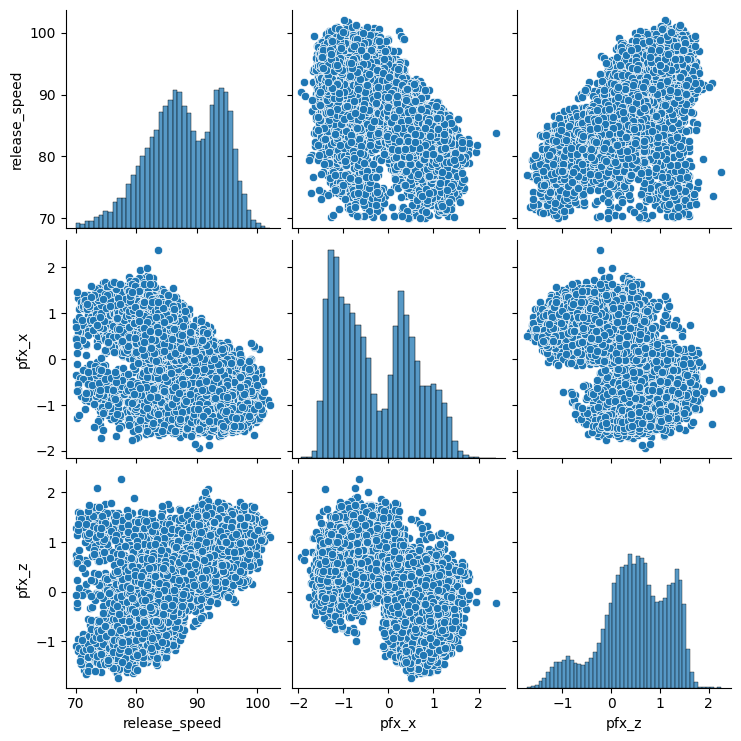

In [7]:
sns.pairplot(
    pitch_type_r,
    vars=["release_speed", "pfx_x", "pfx_z"],
    #hue="pitch_type"
);

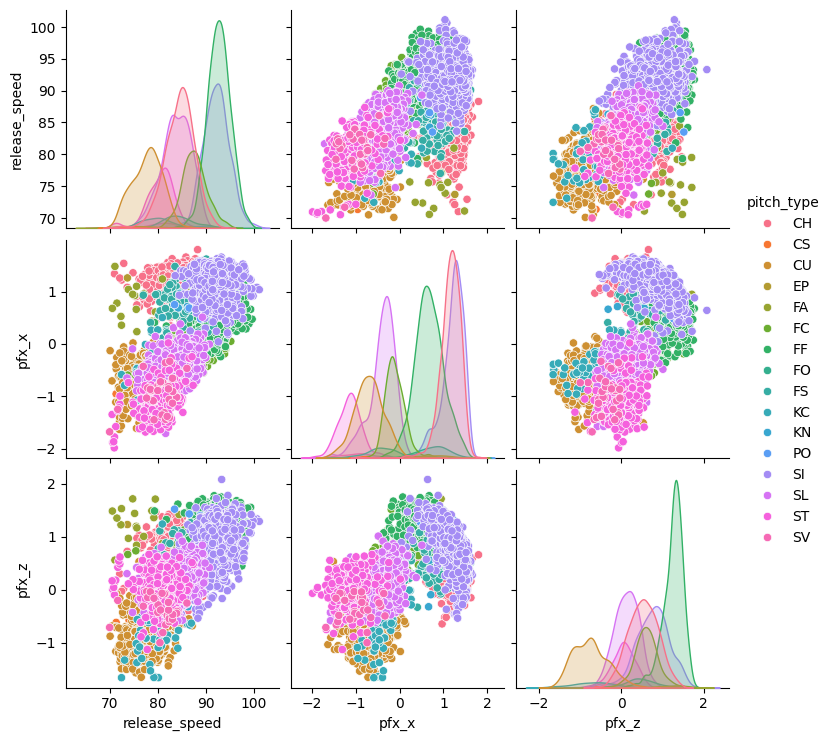

In [8]:
sns.pairplot(
    pitch_type_l,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
);

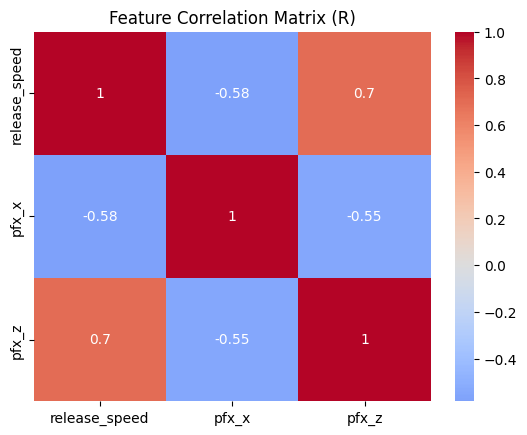

In [9]:
corr_r = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_r, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

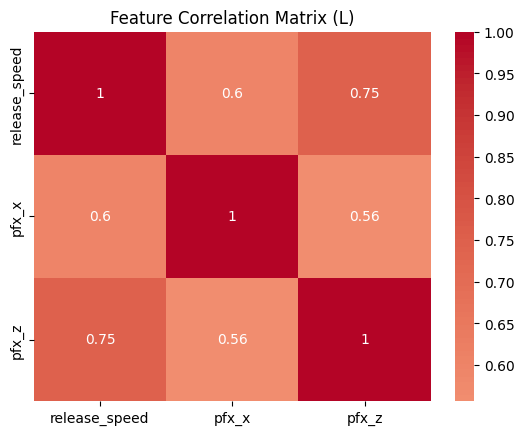

In [10]:
corr_l = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_l, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

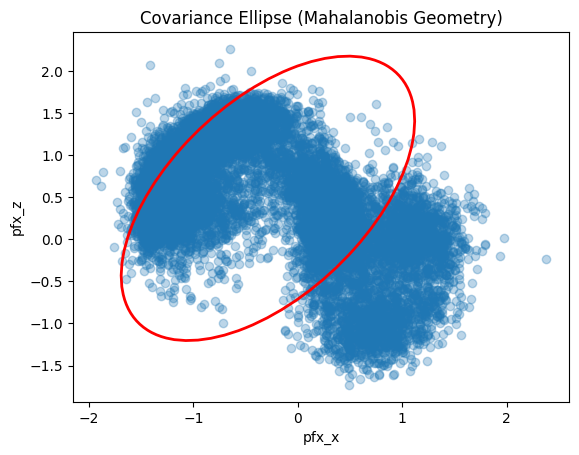

In [11]:
X = pitch_type_r[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

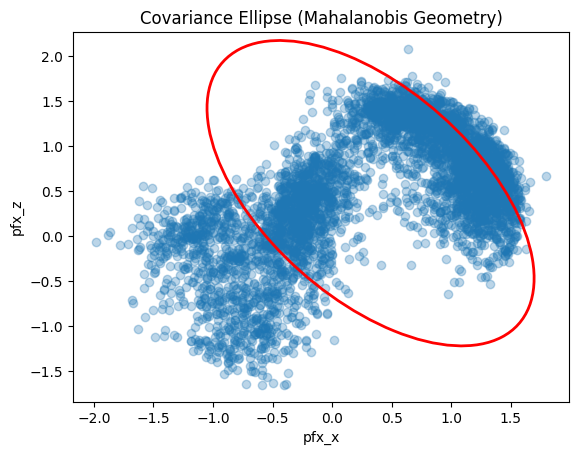

In [12]:
X = pitch_type_l[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

In [13]:
X = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    0.025352
pfx_x            0.005542
pfx_z            0.006024
dtype: float64

In [14]:
X = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    1.714026
pfx_x            0.008860
pfx_z           -0.033997
dtype: float64

# Biomechanics Characteristics

In [15]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
0,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
1,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
2,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
3,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
4,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


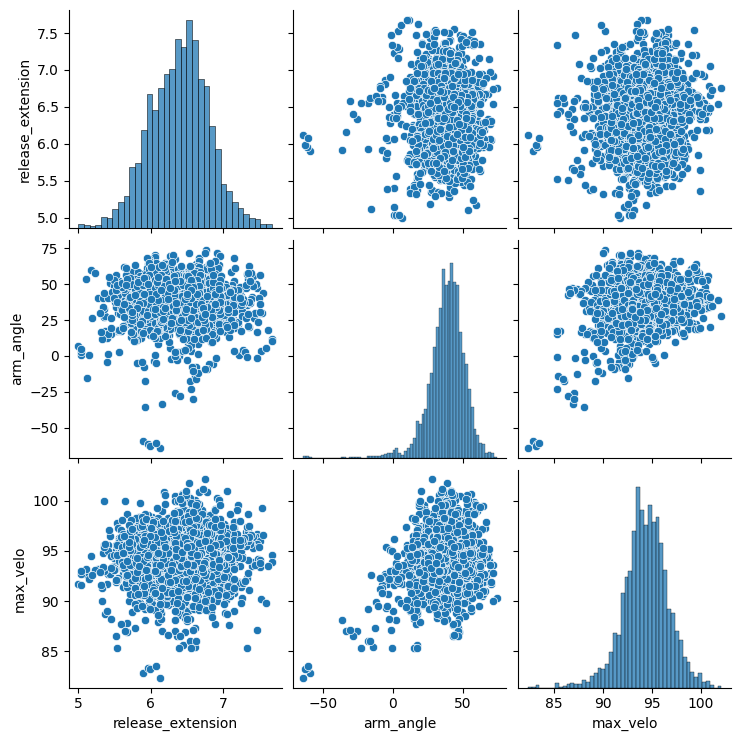

In [16]:
sns.pairplot(
    pitcher_summ_r[pitcher_summ_r['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

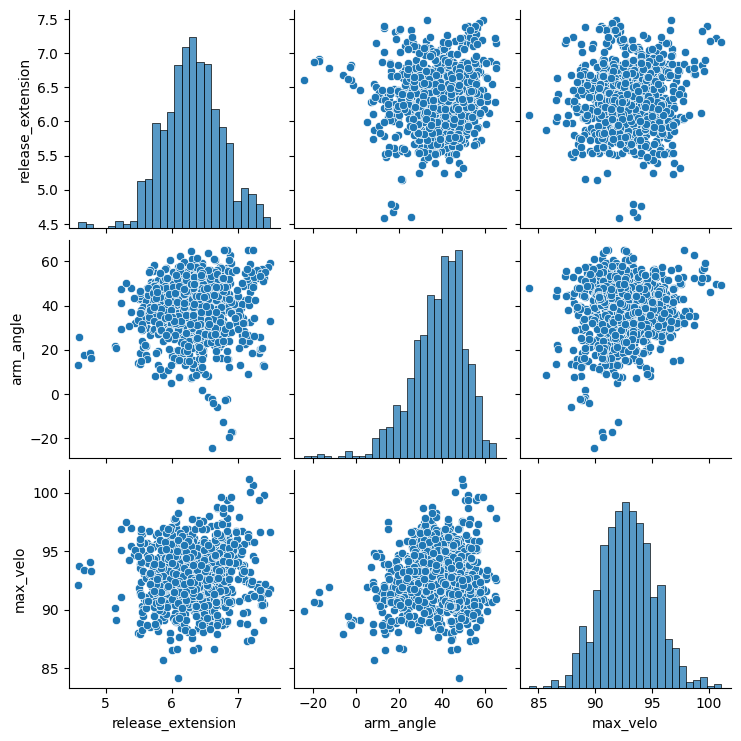

In [17]:
sns.pairplot(
    pitcher_summ_l[pitcher_summ_l['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

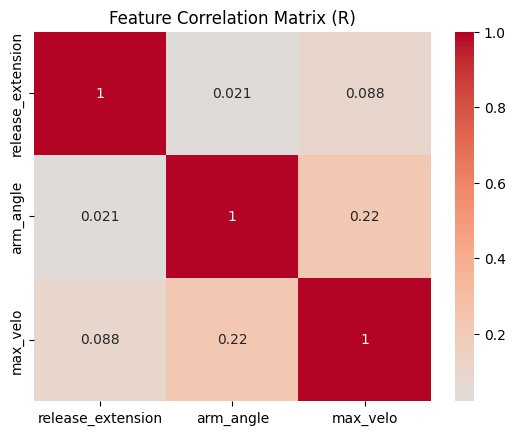

In [18]:
corr = pitcher_summ_r[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

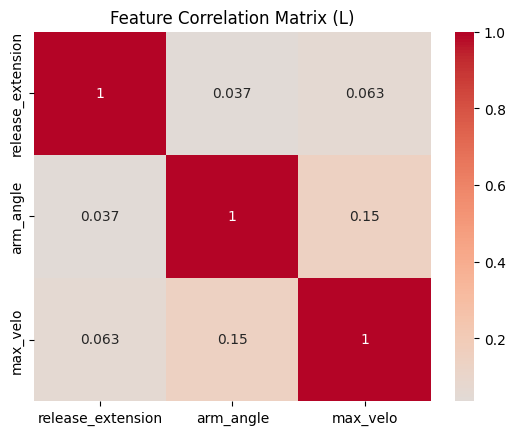

In [19]:
corr = pitcher_summ_l[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

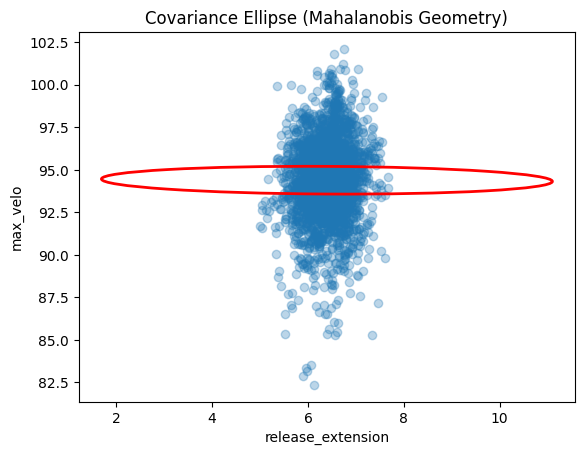

In [20]:
X = pitcher_summ_r[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

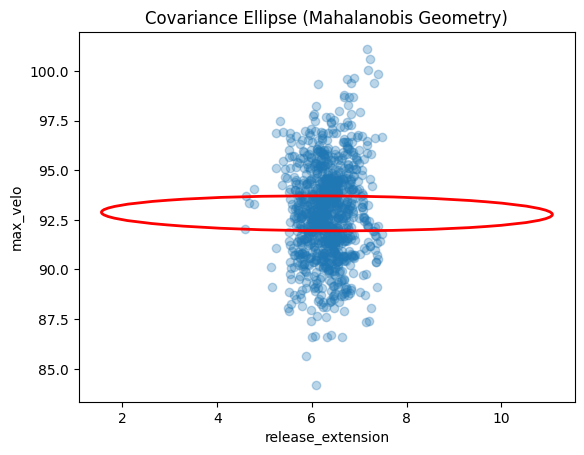

In [21]:
X = pitcher_summ_l[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

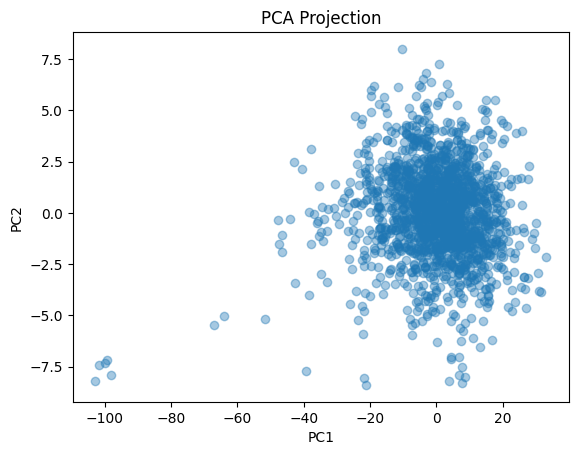

In [22]:
X = pitcher_summ_r[pitcher_summ_r['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

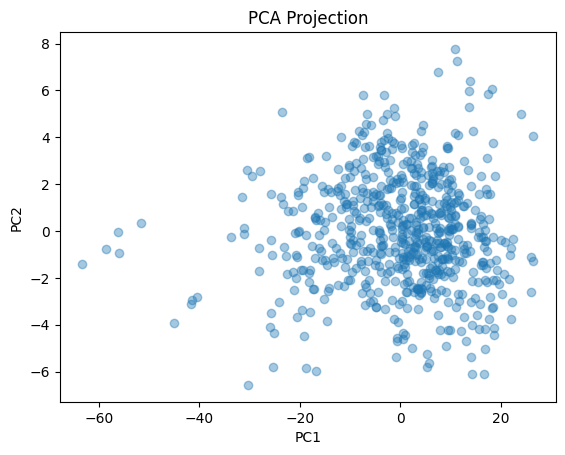

In [23]:
X = pitcher_summ_l[pitcher_summ_l['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

# Hyperparameter Optimization

## Data Prep

In [24]:
pitch_type_distance_r = compute_euclidean_distances(pitch_type_r, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)
pitch_type_distance_l = compute_euclidean_distances(pitch_type_l, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)

Filter to 2025 data only for practical purposes

In [25]:
pitch_type_distance_r_25 = pitch_type_distance_r[(pitch_type_distance_r['game_year1']==2025) & 
    (pitch_type_distance_r['game_year2']==2025)]
pitch_type_distance_l_25 = pitch_type_distance_l[(pitch_type_distance_l['game_year1']==2025) & 
    (pitch_type_distance_l['game_year2']==2025)]

In [26]:
arsenal_comp_l_25 = compare_all_arsenals(pitch_type_distance_l_25, 50)
arsenal_comp_r_25 = compare_all_arsenals(pitch_type_distance_r_25, 50)

2.013743173850861
2.0162059293092662


In [27]:
arsenal_comp_l_25

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
0,"Akin, Keegan",2025,"Bowden, Ben",2025,0.247570
1,"Burke, Brock",2025,"Peralta, Wandy",2025,0.249016
2,"Perdomo, Angel",2025,"Walker, Josh",2025,0.309144
3,"Perdomo, Angel",2025,"Poche, Colin",2025,0.330971
4,"Harrison, Kyle",2025,"Shuster, Jared",2025,0.341067
...,...,...,...,...,...
20095,"Cosgrove, Tom",2025,"Montgomery, Mason",2025,2.641804
20096,"Morán, Jovani",2025,"Rogers, Taylor",2025,2.643458
20097,"Bruihl, Justin",2025,"Cruz, Omar",2025,2.654677
20098,"Bruihl, Justin",2025,"Montgomery, Mason",2025,2.678277


## Define Biomechanics

In [28]:
feature_sets = {
    'current (ext + arm_angle + max_velo + max_spin)':
       ['release_extension', 'arm_angle', 'max_velo', 'max_spin'],
    'current (ext + arm_angle + max_velo)':
       ['release_extension', 'arm_angle', 'max_velo'],
    'current (ext + arm_angle + max_velo + fb_pfx_x)':
       ['release_extension', 'arm_angle', 'max_velo', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + pri_fb_cd)':
        ['release_extension', 'arm_angle', 'max_velo', 'pri_fb_cd'],
    'current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_z', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'release_pos_z', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_z'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x', 'release_pos_z'],
}

In [29]:
pitcher_summ_r_25 = pitcher_summ_r[pitcher_summ_r['game_year']==2025]
pitcher_summ_l_25 = pitcher_summ_l[pitcher_summ_l['game_year']==2025]

In [30]:
results_r_euc = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("RHP:\n", results_r_euc.to_string(index=False))

results_l_euc = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("\nLHP:\n", results_l_euc.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3571      0.0   142311
                                            current (ext + arm_angle + max_velo + max_spin)        0.3673      0.0   142311
            current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)        0.3716      0.0   141246
                            current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)        0.3742      0.0   141246
                                                       current (ext + arm_angle + max_velo)        0.3779      0.0   142311
                            current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)        0.3804      0.0   141246
                                            current (ext + arm_angle + max_velo + fb_pfx_x)        0.3859      0.0   141246
cu

In [31]:
results_r_mah = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("RHP:\n", results_r_mah.to_string(index=False))

results_l_mah = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("\nLHP:\n", results_l_mah.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
            current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)        0.3022      0.0   141246
                            current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)        0.3197      0.0   141246
                            current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)        0.3319      0.0   141246
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3399      0.0   142311
current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)        0.3473      0.0   142311
                                            current (ext + arm_angle + max_velo + fb_pfx_x)        0.3575      0.0   141246
                current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)        0.3627      0.0   142311
  

**No matter how you slice it, extension, arm angle, max velocity, and active spin on the fastball are the best features to define biomechanics**

## Minimum Pitches Tuning

In [32]:
stability_df_biomech, raw_biomech = stability_analysis(statcast_clean_25, 
                                                    ['release_extension', 'arm_angle'],
                                                    sample_sizes = ([5,10,15,20,25,30]),
                                                    n_replicates=100,
                                                    n_pitchers=100
                                                    )

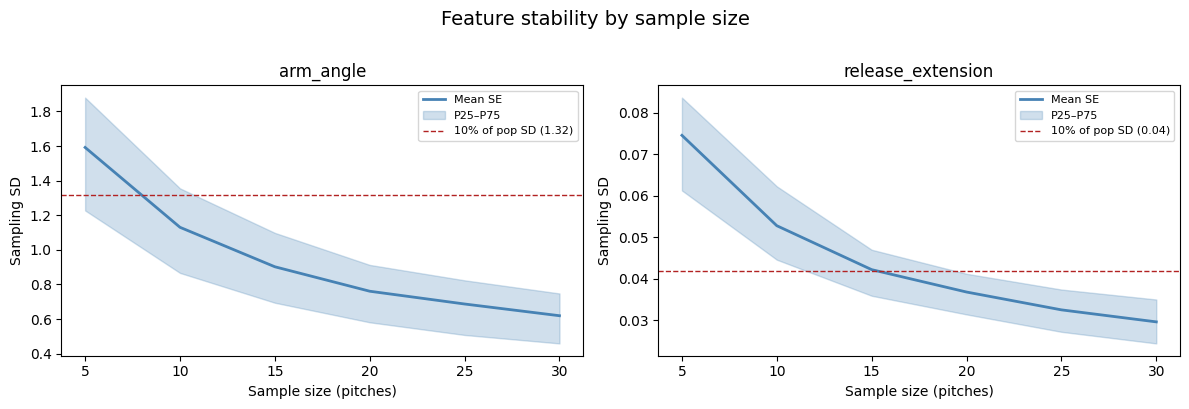

In [33]:
population_sds_biomech = {
    'arm_angle':         pitcher_summ['arm_angle'].std(),
    'release_extension': pitcher_summ['release_extension'].std(),
}
plot_stability(stability_df_biomech, population_sds_biomech)

In [34]:
stability_df_pitch, raw_pitch = stability_analysis(
    statcast_clean_25,
    features=['release_speed', 'pfx_x', 'pfx_z'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30]),
    n_replicates=100,
    n_pitchers=100
)

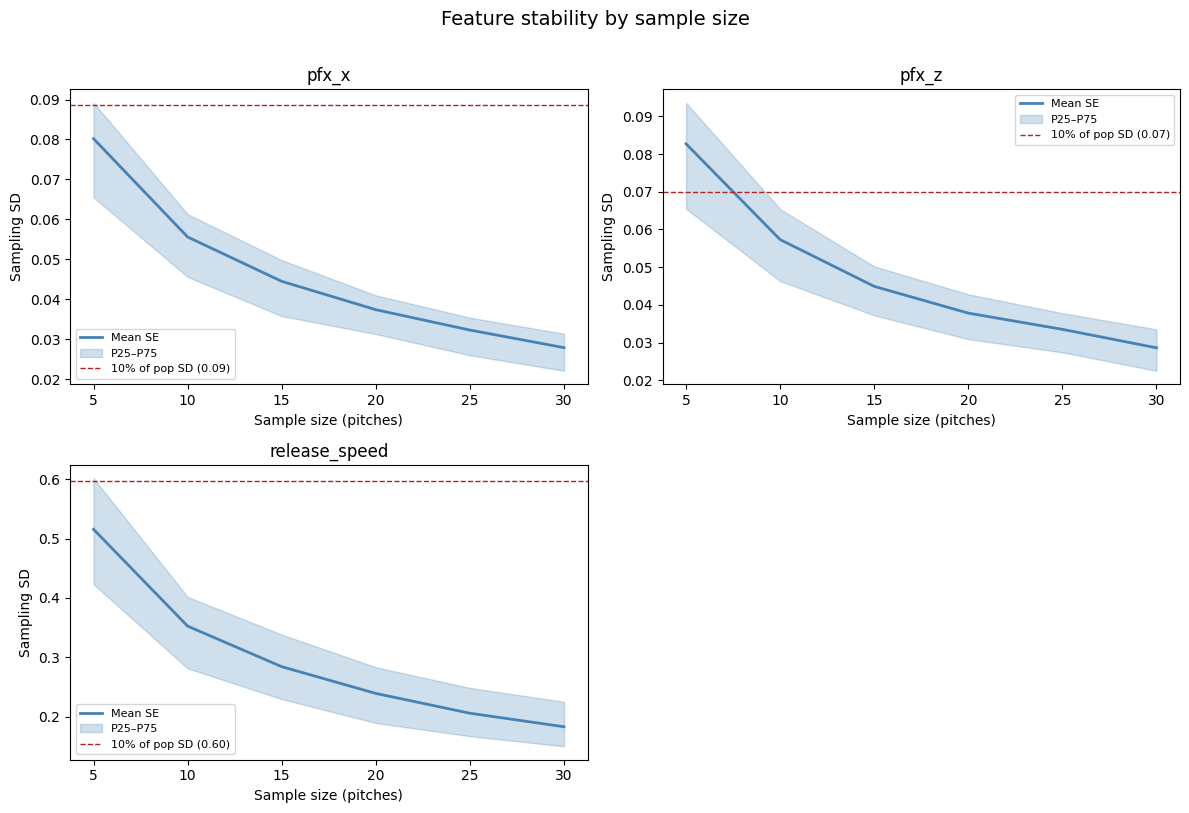

In [35]:
population_sds_pitch = {
    'release_speed': pitch_type_summ['release_speed'].std(),
    'pfx_x':         pitch_type_summ['pfx_x'].std(),
    'pfx_z':         pitch_type_summ['pfx_z'].std(),
}
plot_stability(stability_df_pitch, population_sds_pitch)

In [36]:
stability_df_pitch_ff, raw_pitch_ff = stability_analysis(
    statcast_clean_25[statcast_clean_25['pitch_type']=='FF'],
    features=['release_speed'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30,35,40]),
    n_replicates=100,
    n_pitchers=100
)

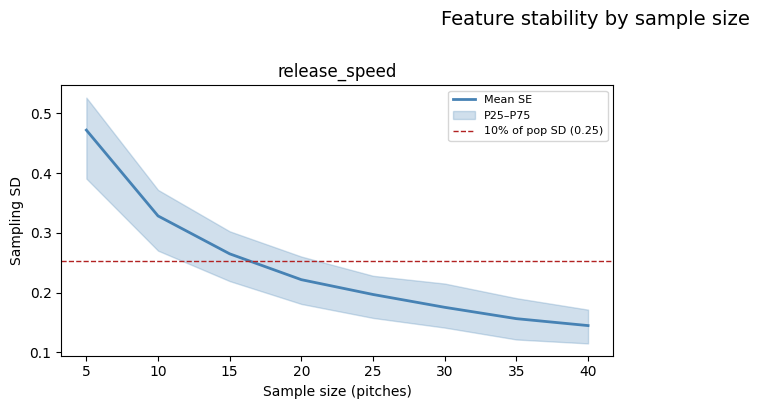

In [37]:
pitch_type_summ_ff = pitch_type_summ[pitch_type_summ['pitch_type']=='FF']
population_sds_pitch_ff = {
    'release_speed': pitch_type_summ_ff['release_speed'].std()
}
plot_stability(stability_df_pitch_ff, population_sds_pitch_ff)

Both pitch characteristics and biomechanical features stabilize very quickly. The slowest feature to stabilize is fastball velocity, and even that is quite differentiable after 20 pitches. We will use 20 pitches as the minimum number of pitches for analysis going forward.

## Arsenal Minimum Distance

In [38]:
global_scaler = StandardScaler().fit(pitch_type_summ[PITCH_CHAR_FEATURES].dropna().values)
arsenal_df = arsenal_internal_distances(pitch_type_summ, global_scaler=global_scaler)

── Arsenal internal distances (across all pitcher-years) ──
       mean_min_dist  min_min_dist  p25_min_dist  p50_min_dist  p75_min_dist  p90_min_dist
count       3753.000      3753.000      3753.000      3753.000      3753.000      3753.000
mean           1.724         1.439         1.445         1.593         1.872         2.087
std            0.659         0.785         0.778         0.697         0.628         0.631
min            0.319         0.044         0.044         0.081         0.319         0.319
25%            1.287         0.910         0.920         1.145         1.457         1.651
50%            1.558         1.201         1.203         1.409         1.754         1.984
75%            1.963         1.758         1.758         1.808         2.115         2.422
max            5.569         5.569         5.569         5.569         5.569         5.569


Min_min_dist shows the minimum distance between any two pitches in an arsenal. For example, if a sinker and fastball are the two most similar pitches in an arsenal, their distance apart will be what goes into the min_min_dist. 

In contrast, the mean_min_dist calculates the mean of every pitch's closest neighbor (FF closest pitch, SI closest pitch, CH closest pitch, etc.)

Since the purpose of this evaluation is to define the minimum threshold for uniqueness to add to an arsenal, I will use the median min_min_dist of about 1.2 as a conservative estimate, meaning that if there is a suggestion for a new pitch, it must be at least as far from every pitch in the current arsenal as the median closest distance.

## Biomechanical Minimum Distance

In [39]:
cov_r = biomech_threshold_coverage(pitcher_summ_r, 
                                   thresholds=(1.0, 1.25, 1.5, 1.75, 2.0),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
      1.00        71.2          6         22         60        111       3.1      8.9
      1.25       135.5         14         48        123        208       2.0      5.2
      1.50       220.3         30         97        213        332       1.2      3.4
      1.75       318.2         60        165        326        469       0.6      2.3
      2.00       420.9        100        263        454        597       0.2      1.7


In [40]:
cov_l = biomech_threshold_coverage(pitcher_summ_l, 
                                   thresholds=(1.0, 1.25, 1.5, 1.75, 2.0),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
      1.00        21.9          2          7         18         33       4.5     17.0
      1.25        42.3          5         16         37         62       2.3      8.5
      1.50        69.8         11         31         67        102       1.4      5.7
      1.75       101.4         21         54        102        145       0.6      3.1
      2.00       136.4         33         82        144        192       0.3      2.3


Find examples of pitchers 1.5 apart


In [41]:
biomech_dist_l = compute_euclidean_distances(
    pitcher_summ_l,
    features=['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    label_cols=['player_name', 'game_year'],
    min_pitches=20,
    include_features=True
)

In [42]:
biomech_dist_l[(biomech_dist_l['distance']>1.4999) & (biomech_dist_l['distance']<1.5001)].tail()

,player_name1,player_name2,game_year1,game_year2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
70012,"Young, Alex","Sears, JP",2023,2024,1.500059,-0.895084,0.204758,-0.657227,-1.342758,-0.661927,-0.380852,-0.009983,0.691138
70013,"Young, Alex","Pennington, Walter",2021,2024,1.500075,-1.252986,-1.076364,-0.358494,-0.765748,-0.571076,-0.549344,-0.081111,-1.513836
70014,"Gilbert, Tyler","Detmers, Reid",2023,2022,1.500083,-0.494265,-1.470709,-0.753841,0.067823,-0.123439,0.143876,0.294852,1.036618
70015,"Davidson, Tucker","Whisenhunt, Carson",2022,2025,1.500090,-0.289958,0.794772,1.696858,0.782743,0.133013,-0.103401,0.548882,0.975651
70016,"Suarez, Ranger","Waddell, Brandon",2023,2025,1.500091,-0.107104,-0.439725,0.135168,0.186113,0.229668,-0.780428,-0.375785,-1.432547


In [43]:
pitcher_summ_l[((pitcher_summ_l['player_name']=='Suarez, Ranger') & (pitcher_summ_l['game_year']==2023)) |
                 ((pitcher_summ_l['player_name']=='Waddell, Brandon') & (pitcher_summ_l['game_year']==2025))]

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
1347,624133,L,"Suarez, Ranger",2023,1.738240,5.877756,6.270079,40.030628,2023,93.374537,2174.862797,SI,1.322504,571.0,0,85.5,FF
2102,663399,L,"Waddell, Brandon",2025,2.683027,6.003164,6.123633,40.673437,512,90.971171,2554.404959,FF,0.278879,116.0,1,75.1,FF


In [44]:
biomech_thresh_l = biomech_threshold_calibration(
    pitcher_summ_l_25,
    arsenal_comp_l_25,
    min_pitches=20,
    n_bins=10,
    max_biomech_dist=3.0,
)

── Biomech threshold calibration ──
 biomech_bin_mid  mean_arsenal  median_arsenal  n_pairs
           0.289        1.0568          0.9893       36
           0.576        1.0215          1.0038      169
           0.861        1.0602          1.0673      481
           1.146        1.1171          1.1185      828
           1.432        1.1276          1.1377     1329
           1.716        1.1757          1.1833     1617
           2.002        1.2199          1.2306     1885
           2.287        1.2605          1.2634     1843
           2.572        1.2946          1.2991     1747
           2.858        1.3553          1.3597     1552


In [45]:
biomech_thresh_r = biomech_threshold_calibration(
    pitcher_summ_r_25,
    arsenal_comp_r_25,
    min_pitches=20,
    n_bins=10,
    max_biomech_dist=3.0,
)

── Biomech threshold calibration ──
 biomech_bin_mid  mean_arsenal  median_arsenal  n_pairs
           0.224        1.0636          1.0745      155
           0.517        1.0822          1.0895     1244
           0.809        1.1075          1.1117     3830
           1.102        1.1214          1.1299     7810
           1.394        1.1584          1.1695    11772
           1.686        1.1876          1.1970    15013
           1.978        1.2192          1.2296    16648
           2.270        1.2583          1.2663    16802
           2.562        1.2940          1.3038    15532
           2.854        1.3263          1.3351    13046


In [46]:
arsenal_comp_r_25.head()

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
0,"Rainey, Tanner",2025,"Romano, Jordan",2025,0.159592
1,"Burr, Ryan",2025,"Poteet, Cody",2025,0.162190
2,"Ginkel, Kevin",2025,"Thompson, Mason",2025,0.168132
3,"Mercado, Michael",2025,"Stephenson, Robert",2025,0.175861
4,"Gillaspie, Logan",2025,"Sanders, Cam",2025,0.189475


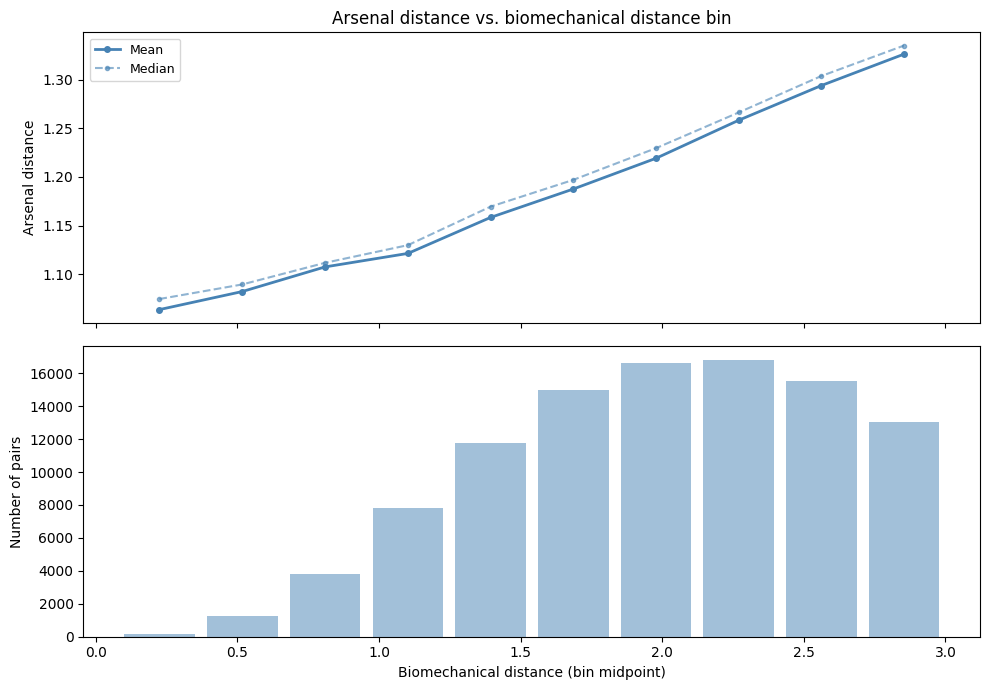

In [47]:
plot_threshold_calibration(biomech_thresh_r)

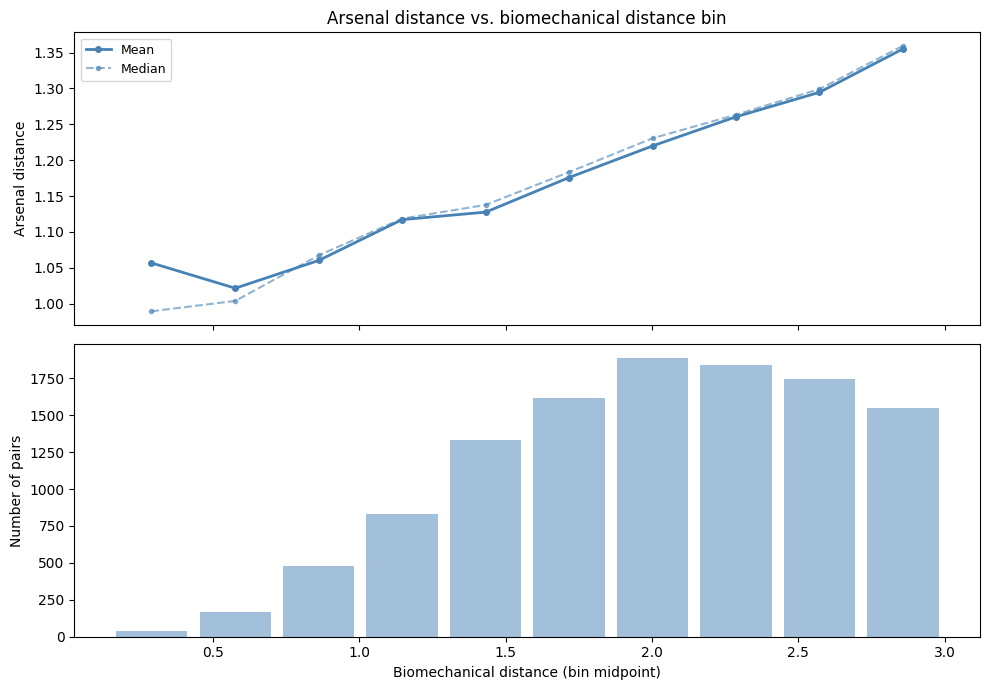

In [48]:
plot_threshold_calibration(biomech_thresh_l)

Going to use 1.5 as a threshold due to solid evidence from both charts. The bottom one shows 1.5 as just before hitting the mass of the data and the biomech_thresh stuff shows 1.5 as a solid compromise. Looking at specific examples validates 1.5 as a good edge case.

## Unique Pitch Cluster Threshold

Not used anymore I think

In [49]:
cluster_mean_sil = real_arsenal_silhouette_scores(statcast_clean_25, min_pitches=20, min_arsenal_size=3)

── Real arsenal silhouette scores ──
count    2787.000
mean        0.588
std         0.138
min         0.035
5%          0.347
10%         0.411
25%         0.501
50%         0.599
max         0.913


In [50]:
print(len(cluster_mean_sil), "clusters total")
cluster_mean_sil.head()

2787 clusters total


,player_name,game_year,pitch_type,sil_score
0,"Abbott, Andrew",2025,ST,0.400397
1,"Abbott, Andrew",2025,FF,0.725725
2,"Abbott, Andrew",2025,CU,0.335562
3,"Abbott, Andrew",2025,CH,0.725249
4,"Abbott, Andrew",2025,FC,0.556125


In [51]:
# How many suggestions get dropped at each threshold?
for thresh in [0.3, 0.35, 0.4, 0.45, 0.5]:
    n_dropped = (cluster_mean_sil['sil_score'] < thresh).sum()
    print(f"{thresh:.2f}: {n_dropped} clusters dropped")

0.30: 89 clusters dropped
0.35: 142 clusters dropped
0.40: 247 clusters dropped
0.45: 429 clusters dropped
0.50: 690 clusters dropped


We will use 0.40 as the silhouette score threshold that pitch clusters need to clear to be valid recommendations. This is about the score of the 10th percentile of all real pitches thrown, meaning our bar to clear for distinctness is a real, but not particularly unqiue or condensed pitch.